# InMAP-Canada Tutorial
This workbook will walk through some manipulations of the InMAP Canada input and output files

## Emissions - Loading, Displaying and Modifying files
Emissions files are in shape (.shp) format, and can be displayed and manipulated with any GIS software or geospatial code package. We will be using Geopandas

In [13]:
import geopandas as gpd 
import numpy as np #matrix functions
import inmap_funcs as ihf #these are functions we wrote to help process data. 
import matplotlib
import matplotlib.pyplot as plt
from geopandas.tools import sjoin

In [9]:
#This cell can be used as scratch/testing space to view outputs, etc.

In [11]:
#Set the file paths for the emissions.
fpath = 'D:/Globus Connect Personal/Data/InMAP/Emissions/'#On my computer
figpath='D:/Globus Connect Personal/Data/InMAP/Figs/20250603/'
#List of scenarios with emissions and output naming schemes, for convenience
scenarios={1:['BASEGM_2015_E010','BASEGM_2015_017'],2:['BAU_2020_E108','BAU_2020_105'],3:['BAU_2025_E107','BAU_2025_106'],4:['BAU_2030_E107','BAU_2030_106'],
5:['BAU_2035_E107','BAU_2035_106'],6:['BPT_2015_E002','BPT_2015_002'],7:['BPT_2015_E006','BPT_2015_006'],
8:['BPT_2015_E015','BPT_2015_015'],9:['COVID_2020_E003','COVID_2020_003'],10:['BPT_2015_E016','BPT_2015_016']}
#List the pollutants to display
listvals=['NH3','NOx','PM25','SOx','VOC']
loadfile=True #False
dopts=True #This flag says if you have point or gridded major emissions.
sumemissions=True
crs='ESRI:102002'
#Next, we load the files
sID = 1 #define which one of the scenarios from dict
scenario = scenarios[sID][0]
#Load in the area emissions
areaemissions = gpd.read_file(fpath+scenario+'_area.shp').to_crs(crs)
#Load the major emissions. Note that the points files are slow!
majoremissions=gpd.read_file(fpath+scenario+'_majorpts.shp').to_crs(crs)
#Add a sum of emissions if major emissions are gridded.
allemissions = areaemissions.copy(deep=True) 
if dopts:
    pass
else:
    allemissions.loc[:,listvals]=allemissions.loc[:,listvals]+majoremissions.loc[:,listvals]
print('loaded and summed for '+scenario)

loaded and summed for BASEGM_2015_E010


In [34]:
#import inmap_funcs as ihf

In [30]:
#Bring in outlines of provinces
#Join provinces to output. This is very slow
sjoinem=True
if sjoinem:
    provinces = gpd.read_file(r"D:\Globus Connect Personal\Data\InMAP\Outputs\provinces_lcc2.gpkg")    
    allemissions = sjoin(allemissions, provinces.loc[:,['PRENAME','geometry']], how='left',predicate='intersects')
    majoremissions = sjoin(majoremissions, provinces.loc[:,['PRENAME','geometry']], how='left',predicate='intersects')
allemissions.head()

,NH3,NOx,PM25,SOx,VOC,geometry,index_right,PRENAME
0,0.0,0.0,0.0,0.0,0.0,"POLYGON ((2732527.967 4636950.509, 2732527.967...",NaN,NaN
1,0.0,0.0,0.0,0.0,0.0,"POLYGON ((2742530.628 4636950.509, 2742530.628...",NaN,NaN
2,0.0,0.0,0.0,0.0,0.0,"POLYGON ((2752533.289 4636950.509, 2752533.289...",NaN,NaN
3,0.0,0.0,0.0,0.0,0.0,"POLYGON ((2762535.950 4636950.509, 2762535.950...",NaN,NaN
4,0.0,0.0,0.0,0.0,0.0,"POLYGON ((2772538.610 4636950.509, 2772538.610...",NaN,NaN


4


C:\Users\trodge01\AppData\Local\Temp\ipykernel_51052\592943923.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


plotted BASEGM_2015_E010


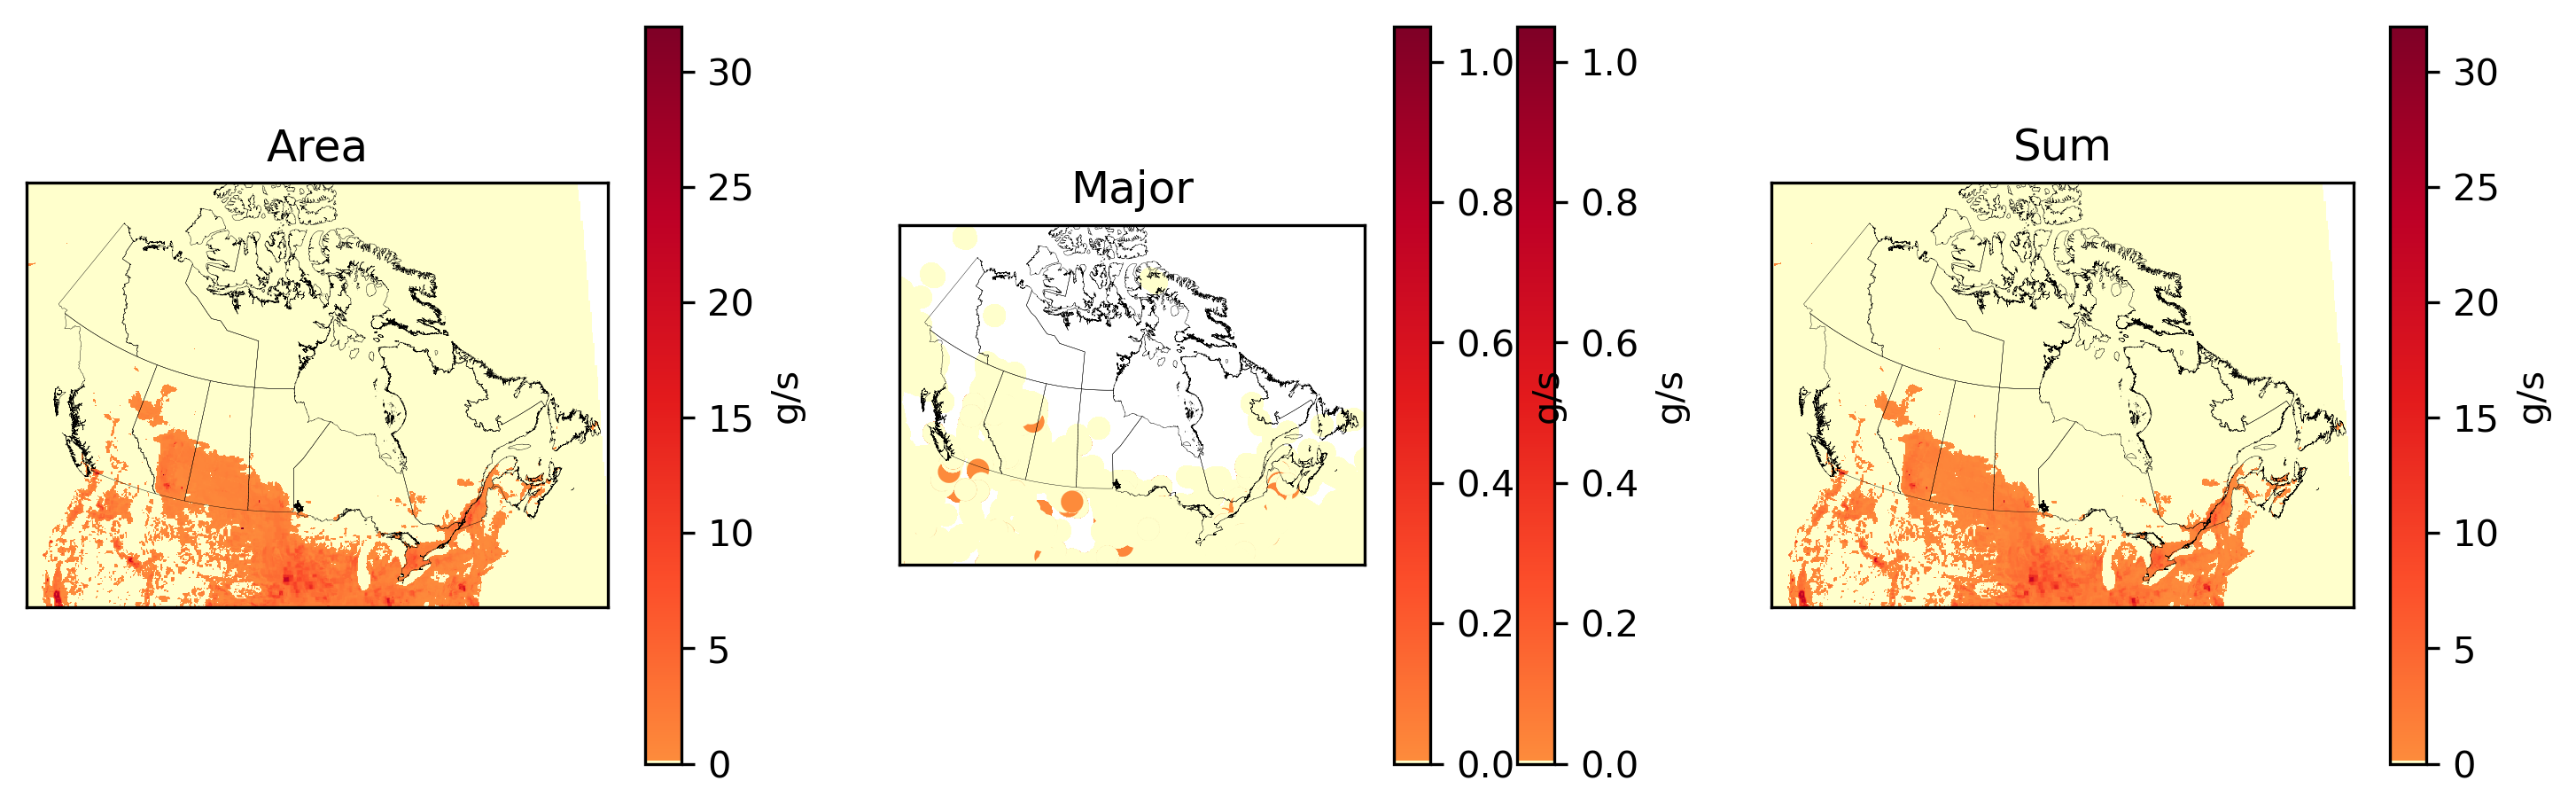

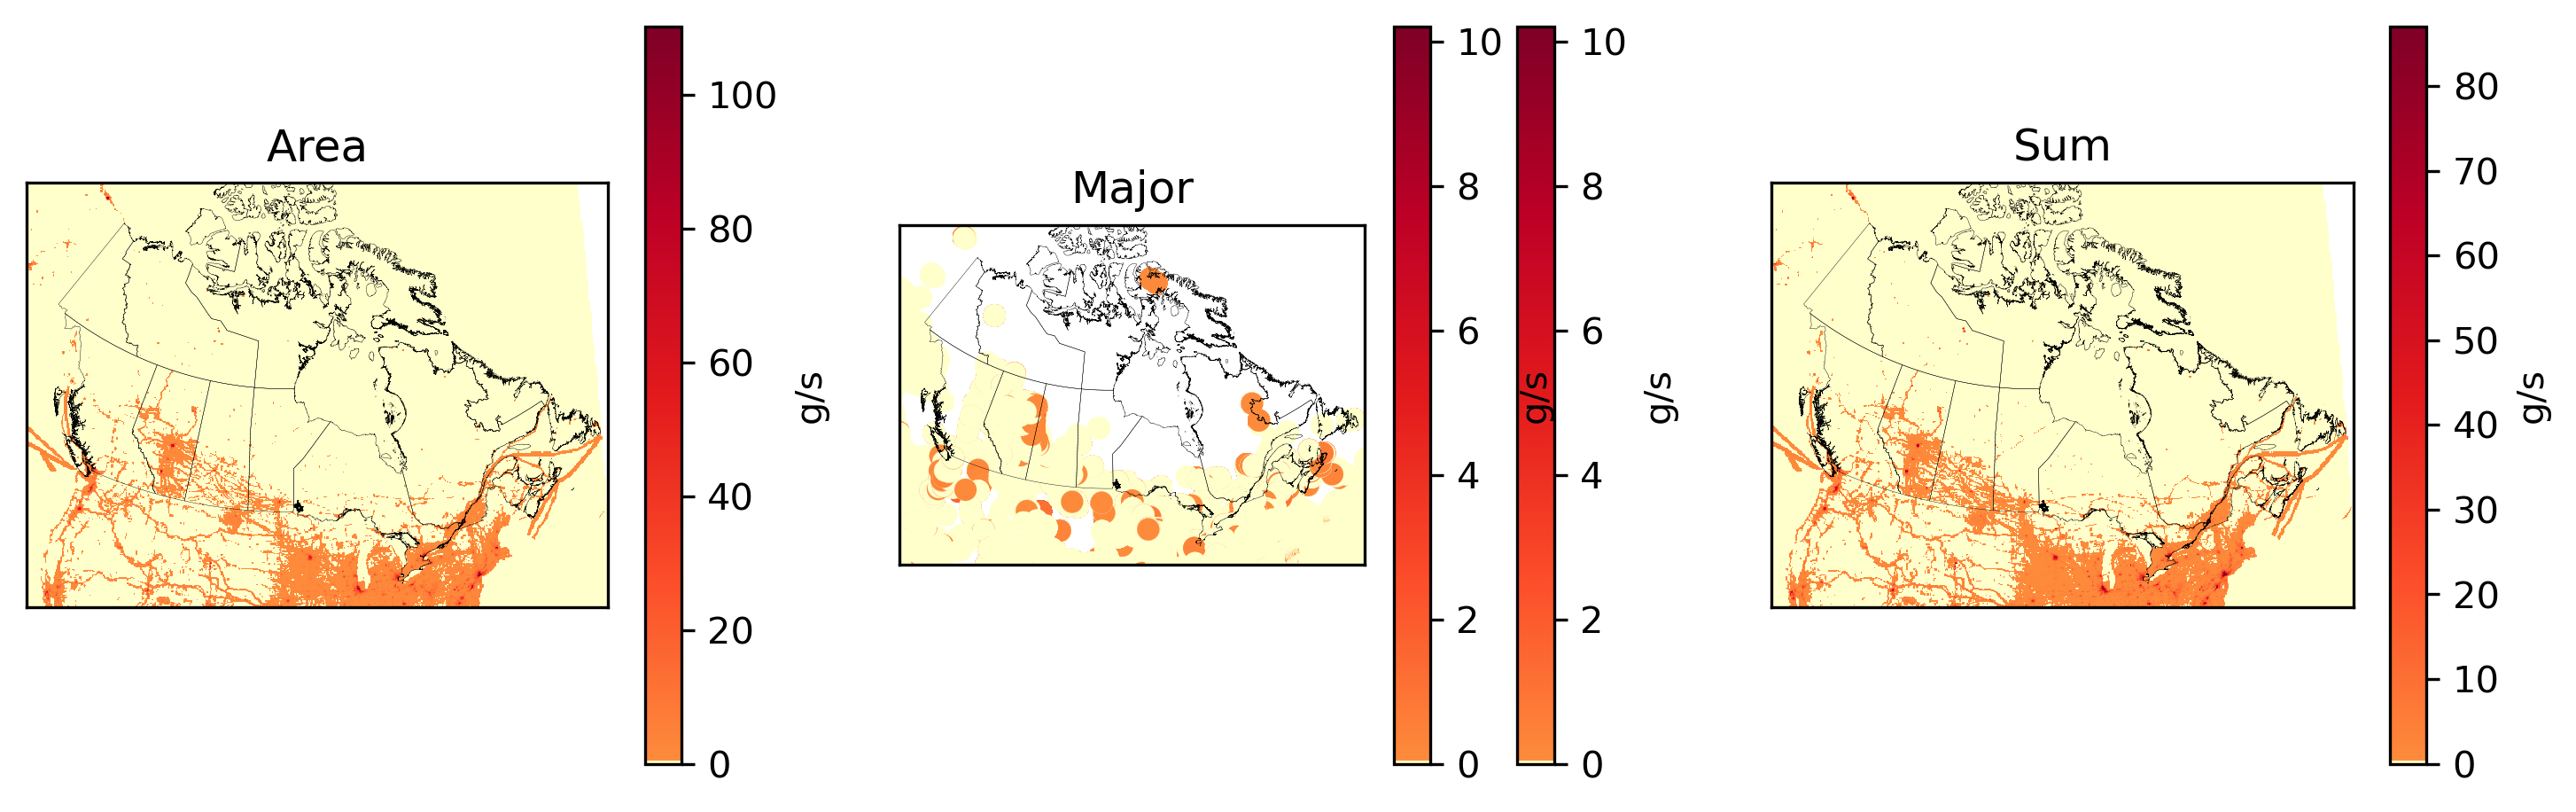

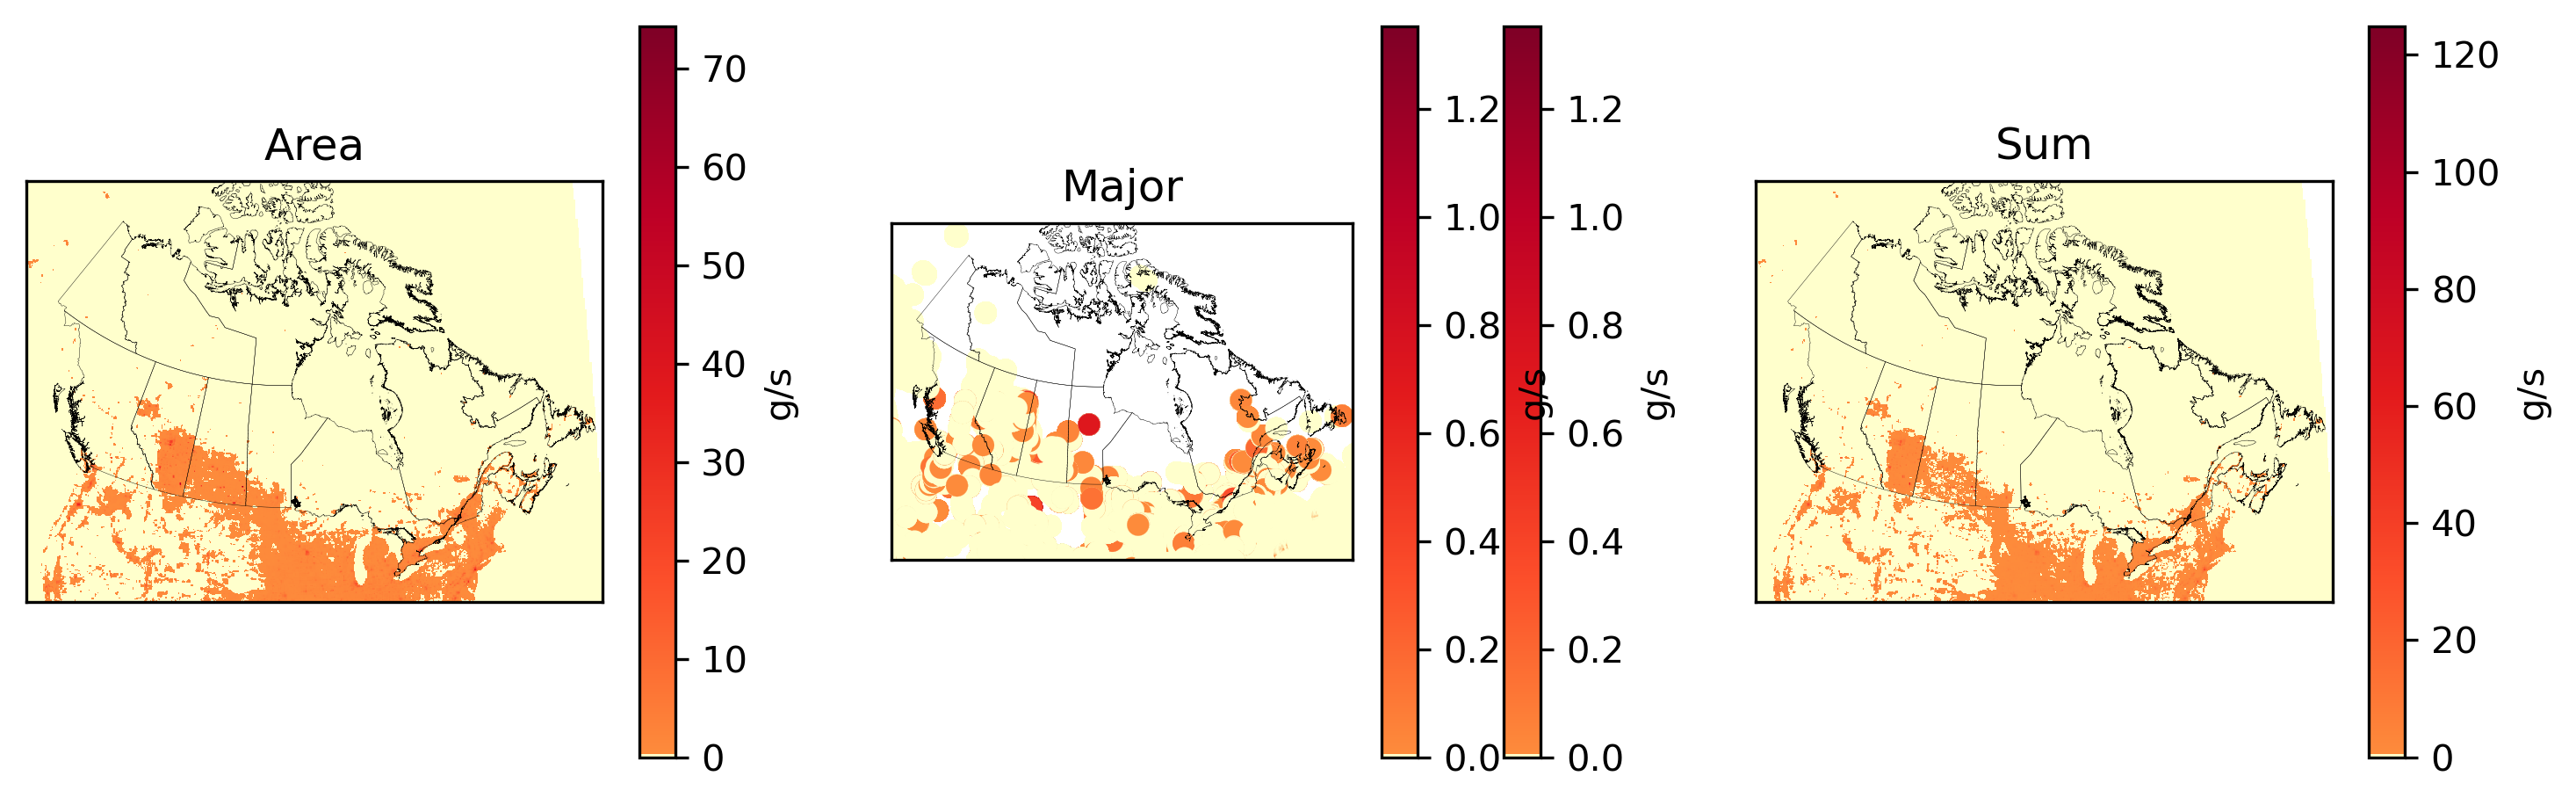

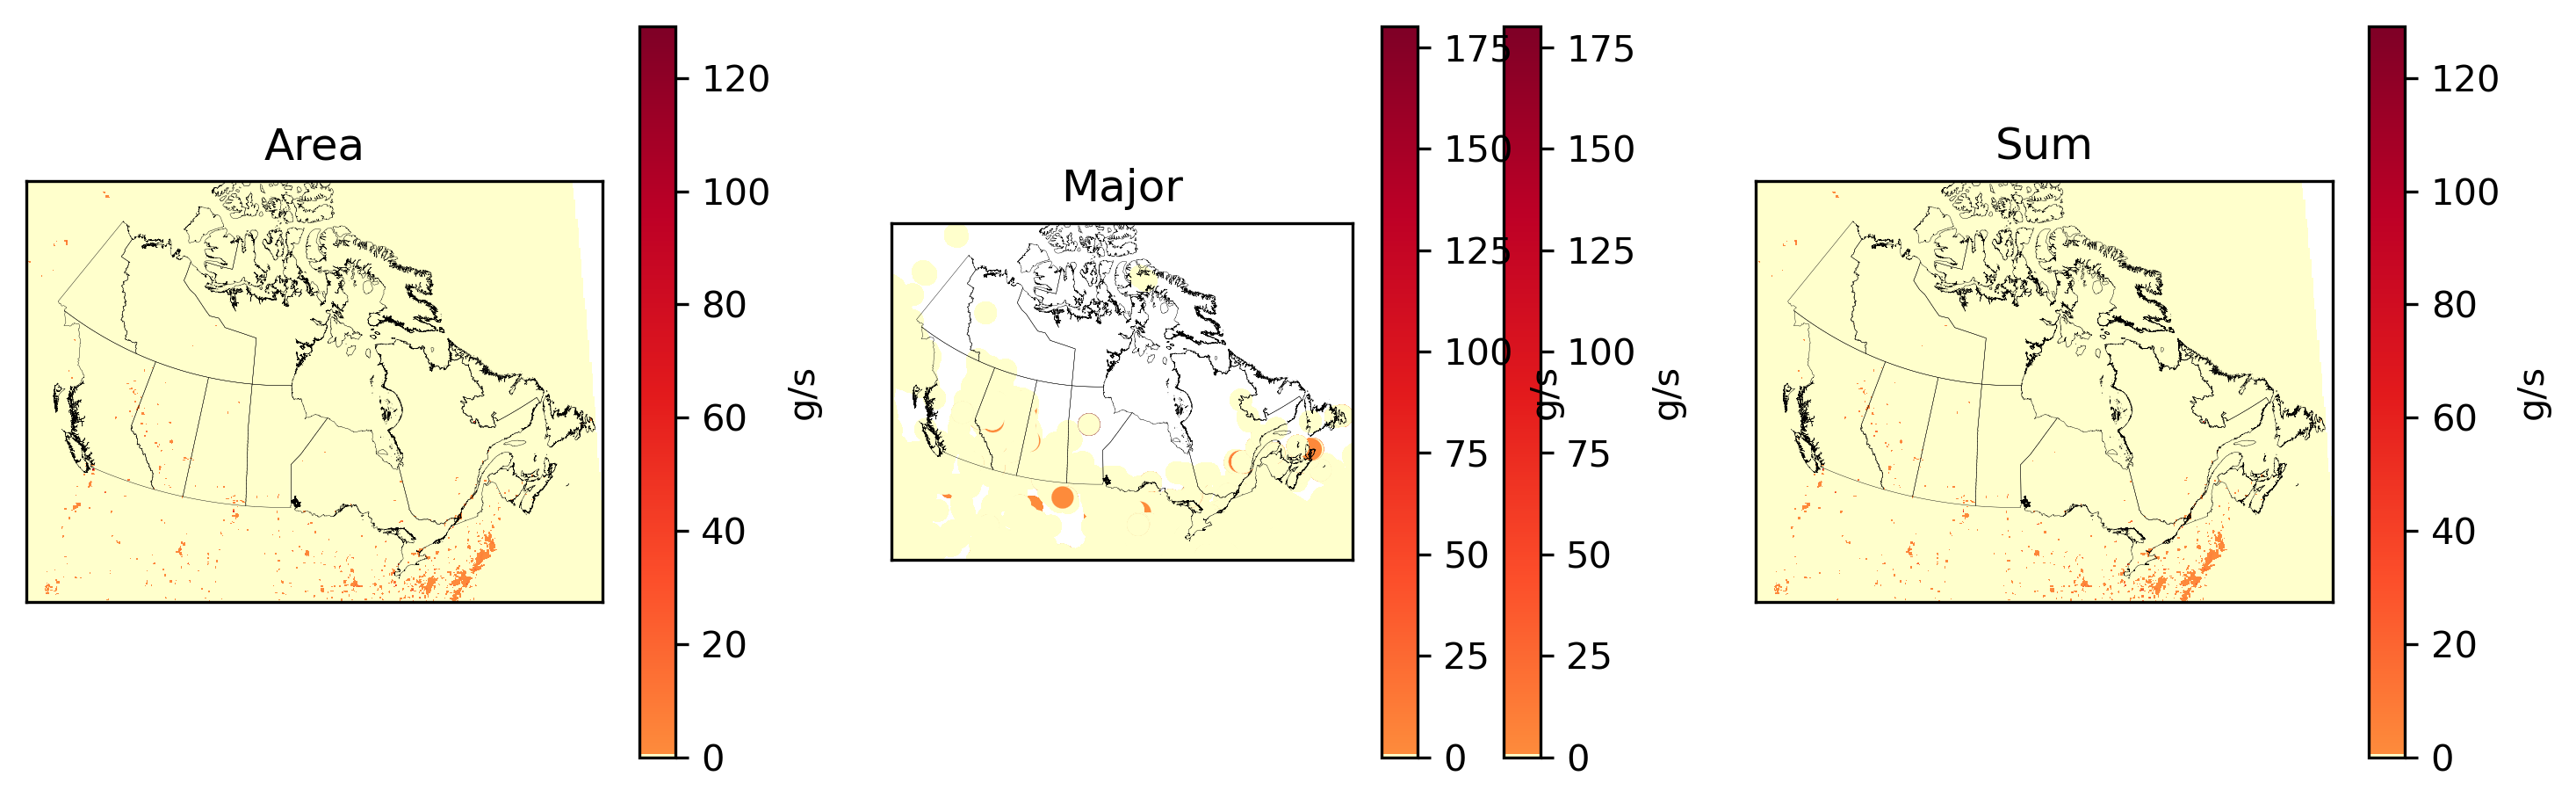

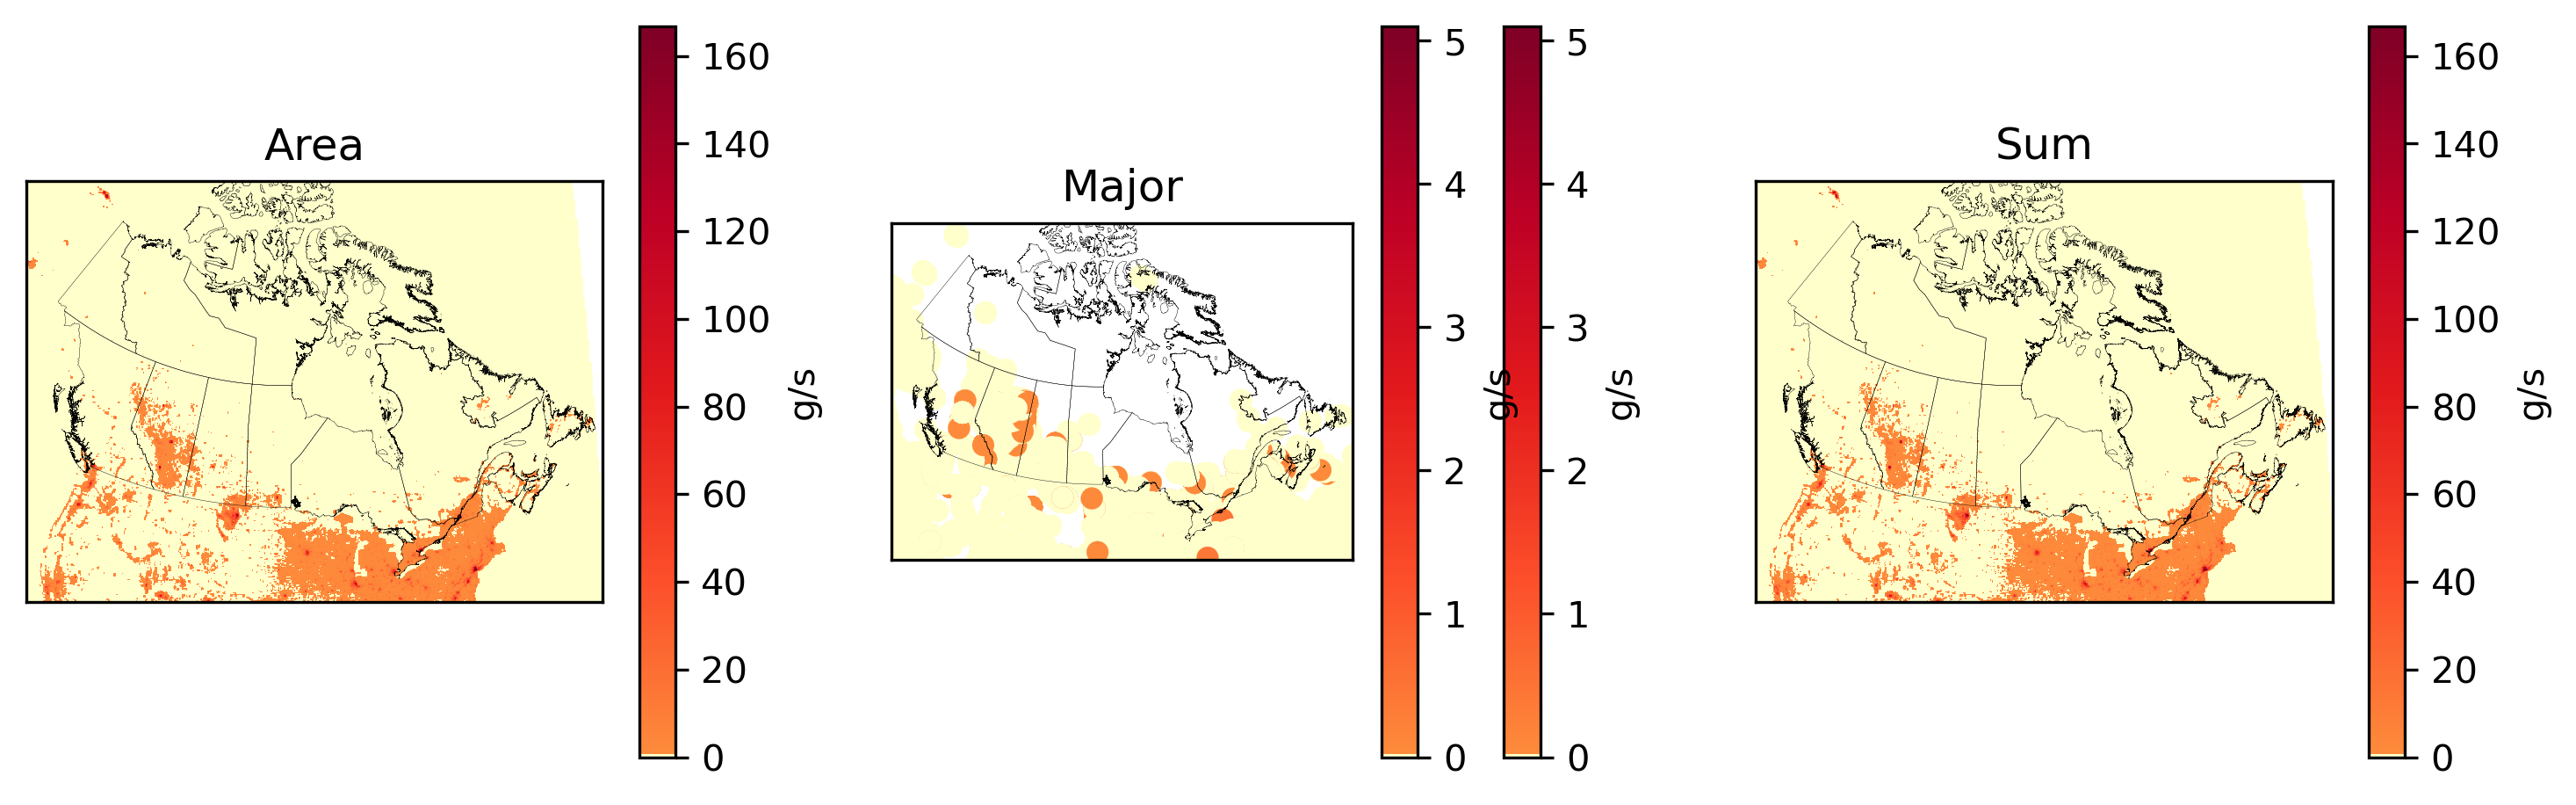

In [31]:
#Next, use the plotting function that we have defined to plot the emissions.
emisslist=[areaemissions, majoremissions,allemissions] #area, major, combined
#most of the options here are cosmetic, see the function in inmap_funcs for full details
#pdb.set_trace()
cmap=matplotlib.cm.YlOrRd
fig = ihf.plot_emissions(emisslist,provinces,legend=True,lgdshk = 0.3,lnwdth = 0.05,sjoinem=False,
                     alpha = 1.0,cmap=cmap,listvals=listvals,figpath=figpath,scenario=scenario,dopts=dopts)
fig.show()
print('plotted '+scenario)

In [ ]:
#If we want to modify the emissions, we need to manipulate the inputs and then save again
#Let's say we want to drop NOx by 10% everywhere:
areaemissions.loc[:,'NOx'] = 0.9*areaemissions.loc[:,'NOx']
#Then we export with geopandas.
areaemissions.to_file(fpath+scenario+'_area'+suffix[:-4]+'_90pct.shp')
majoremissions.loc[:,'NOx'] = 0.9*majoremissions.loc[:,'NOx']
majoremissions.to_file(fpath+scenario+'_major'+suffix[:-4]+'_90pct.shp')
#Then, you can modify the .toml file when you run next to use this scenario
print(fpath+scenario+'_area'+suffix[:-4]+'_90pct.shp ,'+fpath+scenario+'_major'+suffix[:-4]+'_90pct.shp')

In [ ]:
#If you wanted to modify just ontario, can select using the provincial info e.g.:
#Note that you'd have to spatial join the area emissions to the provinces to do this for them.
majoremissions.loc[majoremissions.PRENAME=='Ontario','NOx'] = 0.9*majoremissions.loc[majoremissions.PRENAME=='Ontario','NOx']

## InMAP Outputs - Loading, summary stats, displaying files
Output files are likewise in shape (.shp) format, and can be displayed and manipulated with any GIS software or geospatial code package.


In [33]:
#Plot Concentrations vs GEMMACH and generate summary statistics
fpath = 'D:/Globus Connect Personal/Data/InMAP/Outputs/'
figpath='D:/Globus Connect Personal/Data/InMAP/Figs/20250603/'
#List pairs of base and output emissions
pairs=[['BasePM25','TotalPM25'],['BasePNO3','PNO3'],['BasePNH4',
        'PNH4'],['BasePSO4','PSO4'],['BaseSOA','SOA'],['BasePrimPM25','PrimPM25']]
#Stats that will be calculated. This is the full list, can modify if you want fewer.
stats = ['RMSE', 'MeanBias', 'MeanError', 'MeanFractionalBias', 
        'MeanFractionalError', 'ModelRatio', 'Regression']
#Regions for summary statistics - in this case by province
geoareas = ['Canada','British Columbia', 'Quebec', 'Nunavut', 'Prince Edward Island',
 'Saskatchewan', 'Yukon', 'Manitoba', 'Ontario', 'New Brunswick', 'Northwest Territories',
 'Alberta', 'Newfoundland and Labrador', 'Nova Scotia']
prefix='20231218pts_InmapOuts_'
#Define the ID of the scenario
sIDs = [1]
scenario = scenarios[sID][1]#Set the scenario name 
calcdelta=True #Flag to calculate the difference between GEMMACH and InMAp
loadfile=True #Flag to load the file (vs using previously loaded)
#Extent to be mapped
xylims=[(-2579201.070414297,3165870.),(76856.48815160134,4270028.)] #All of Canda
#xylims=[(-2200000,-1300000),(1190000,1800000)] #BC 
#xylims=[(1088000,1900000),(332000,1250000)] #ON-QC Corridor
if loadfile:
    inmap_outs = ihf.load_inmap(fpath+prefix+scenario+'.shp',basefile=None,crs='ESRI:102002',clipped=False)
    #Add provinces to get summary statistics
    provinces = gpd.read_file(r"D:\Globus Connect Personal\Data\InMAP\Outputs\provinces_lcc2.gpkg")
    inmap_outs = sjoin(inmap_outs, provinces.loc[:,['PRENAME','geometry']], how='left',predicate='intersects')
#'Base' data is the GEMMACH output. 
if calcdelta:
    for vals in [['BasePM25','TotalPM25'],['BasePNO3','PNO3'],['BasePNH4',
                      'PNH4'],['BasePSO4','PSO4'],['BaseSOA','SOA'],['BasePrimPM25','PrimPM25']]:
        delname = 'delta_'+vals[0][4:]
        if vals[0] == 'BasePrimPM25':
            #Need to calculate out primary PM2.5 in the base scenario
            inmap_outs.loc[:,vals[0]] = (inmap_outs.BasePM25) - (inmap_outs.loc[:,['BasePNO3','BasePNH4','BasePSO4','BaseSOA']].sum(axis=1))
        inmap_outs.loc[:,delname] = inmap_outs.loc[:,vals[1]] - inmap_outs.loc[:,vals[0]] 

C:\Users\trodge01\AppData\Local\Temp\ipykernel_51052\229025525.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


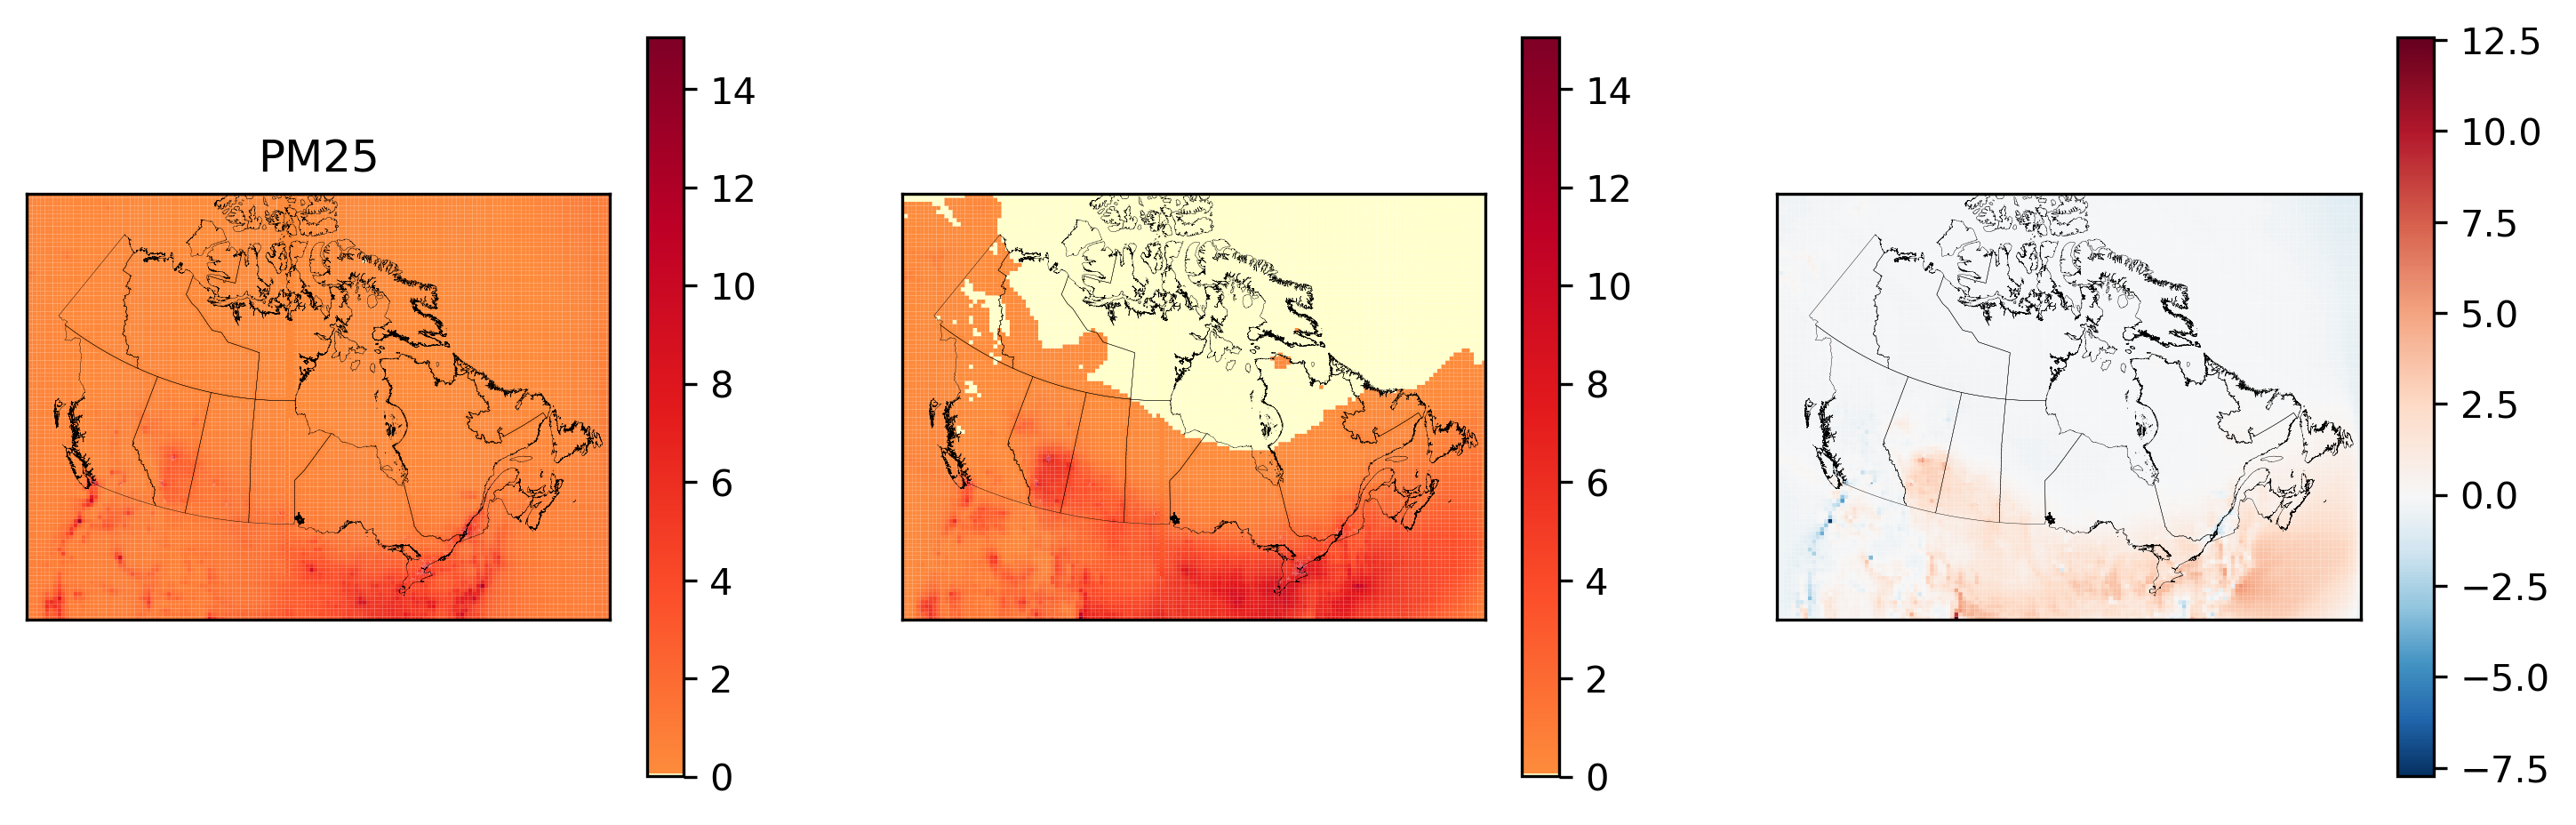

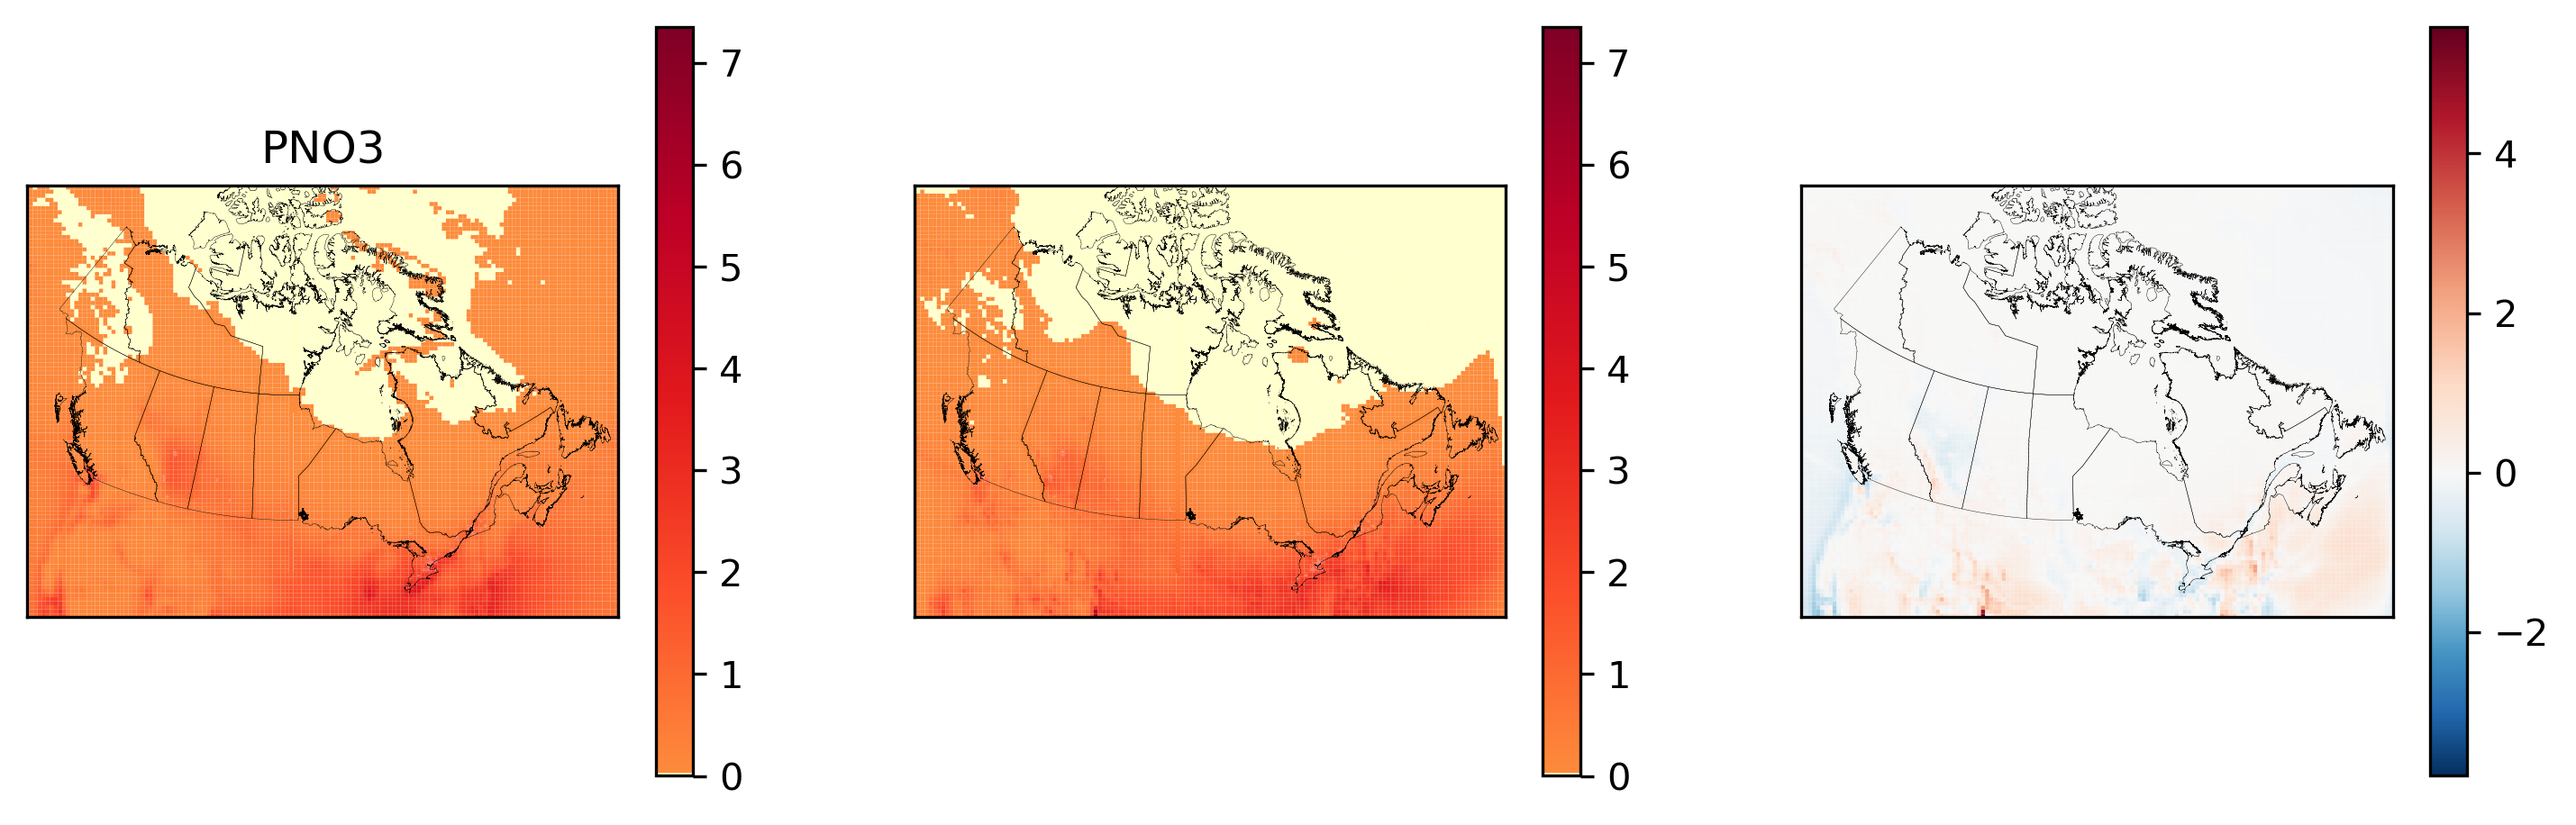

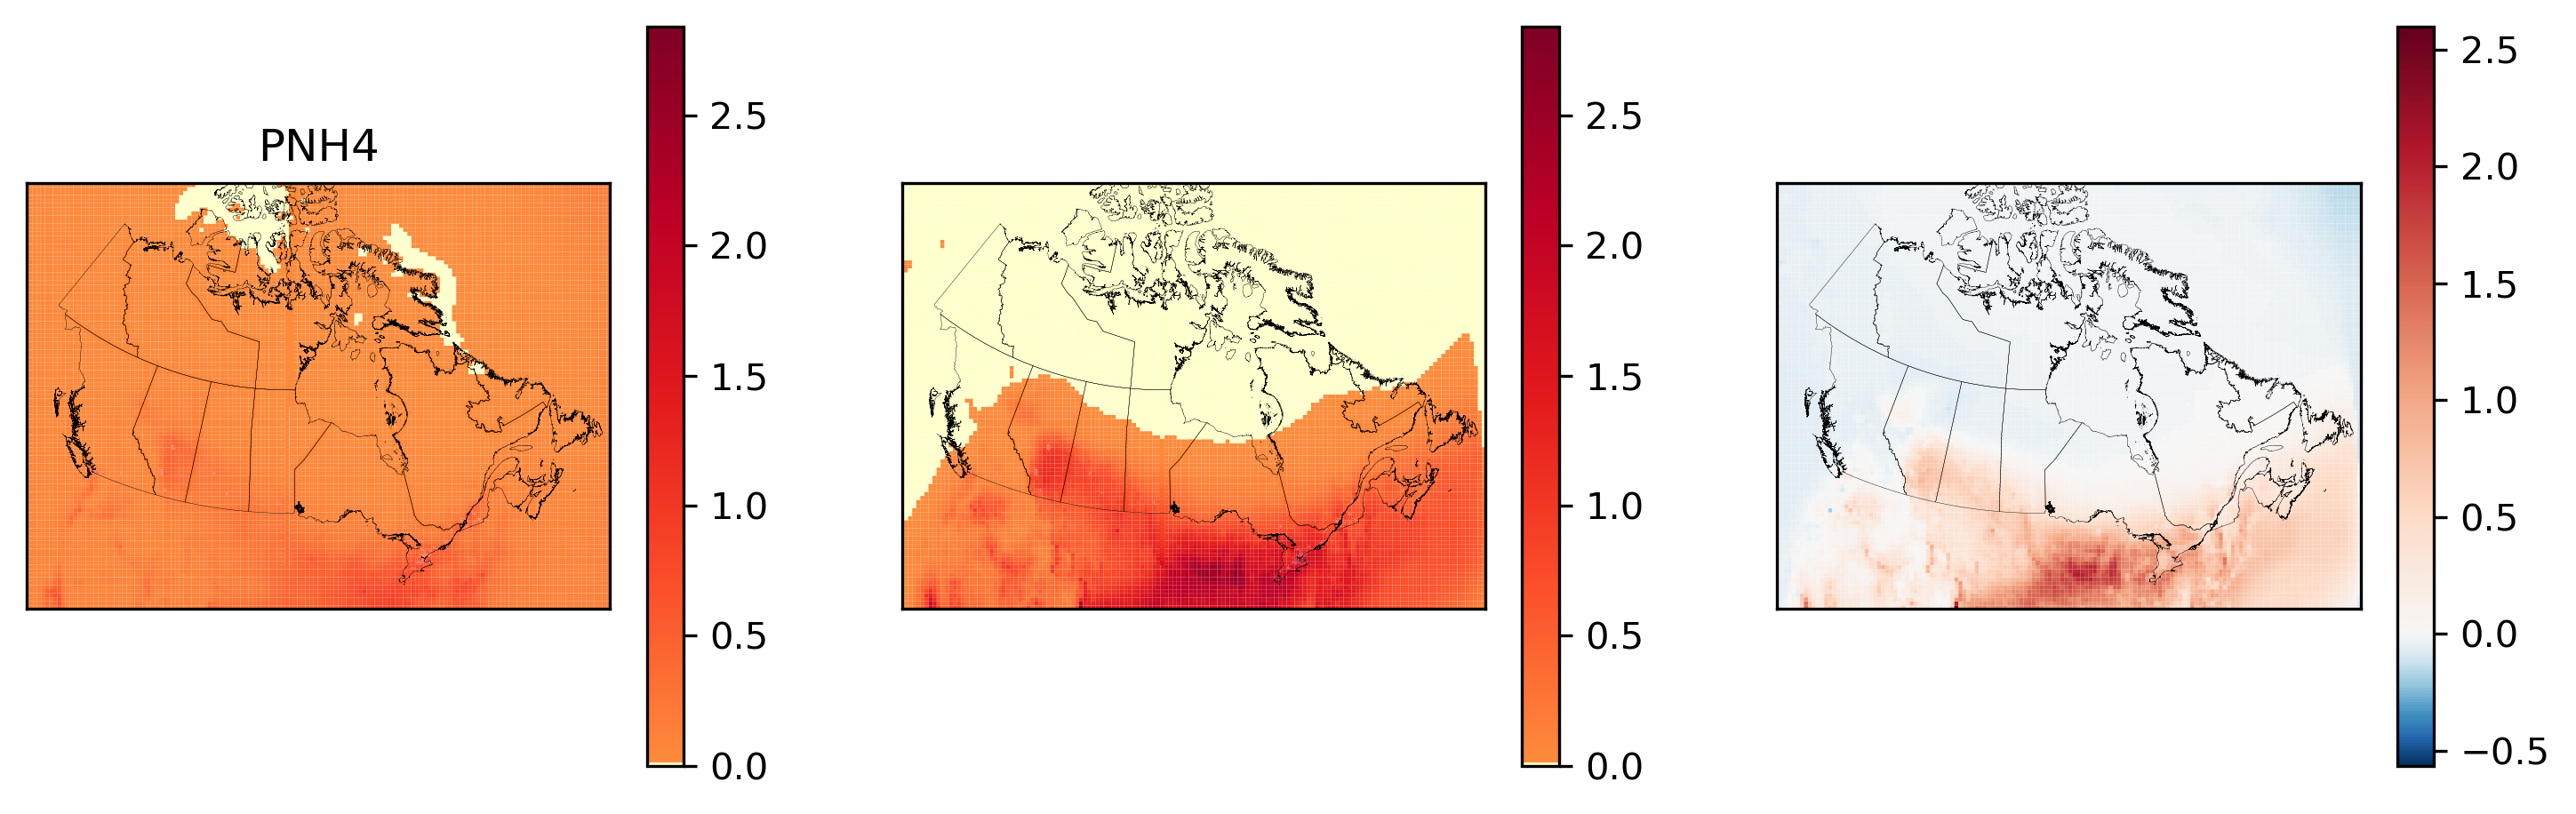

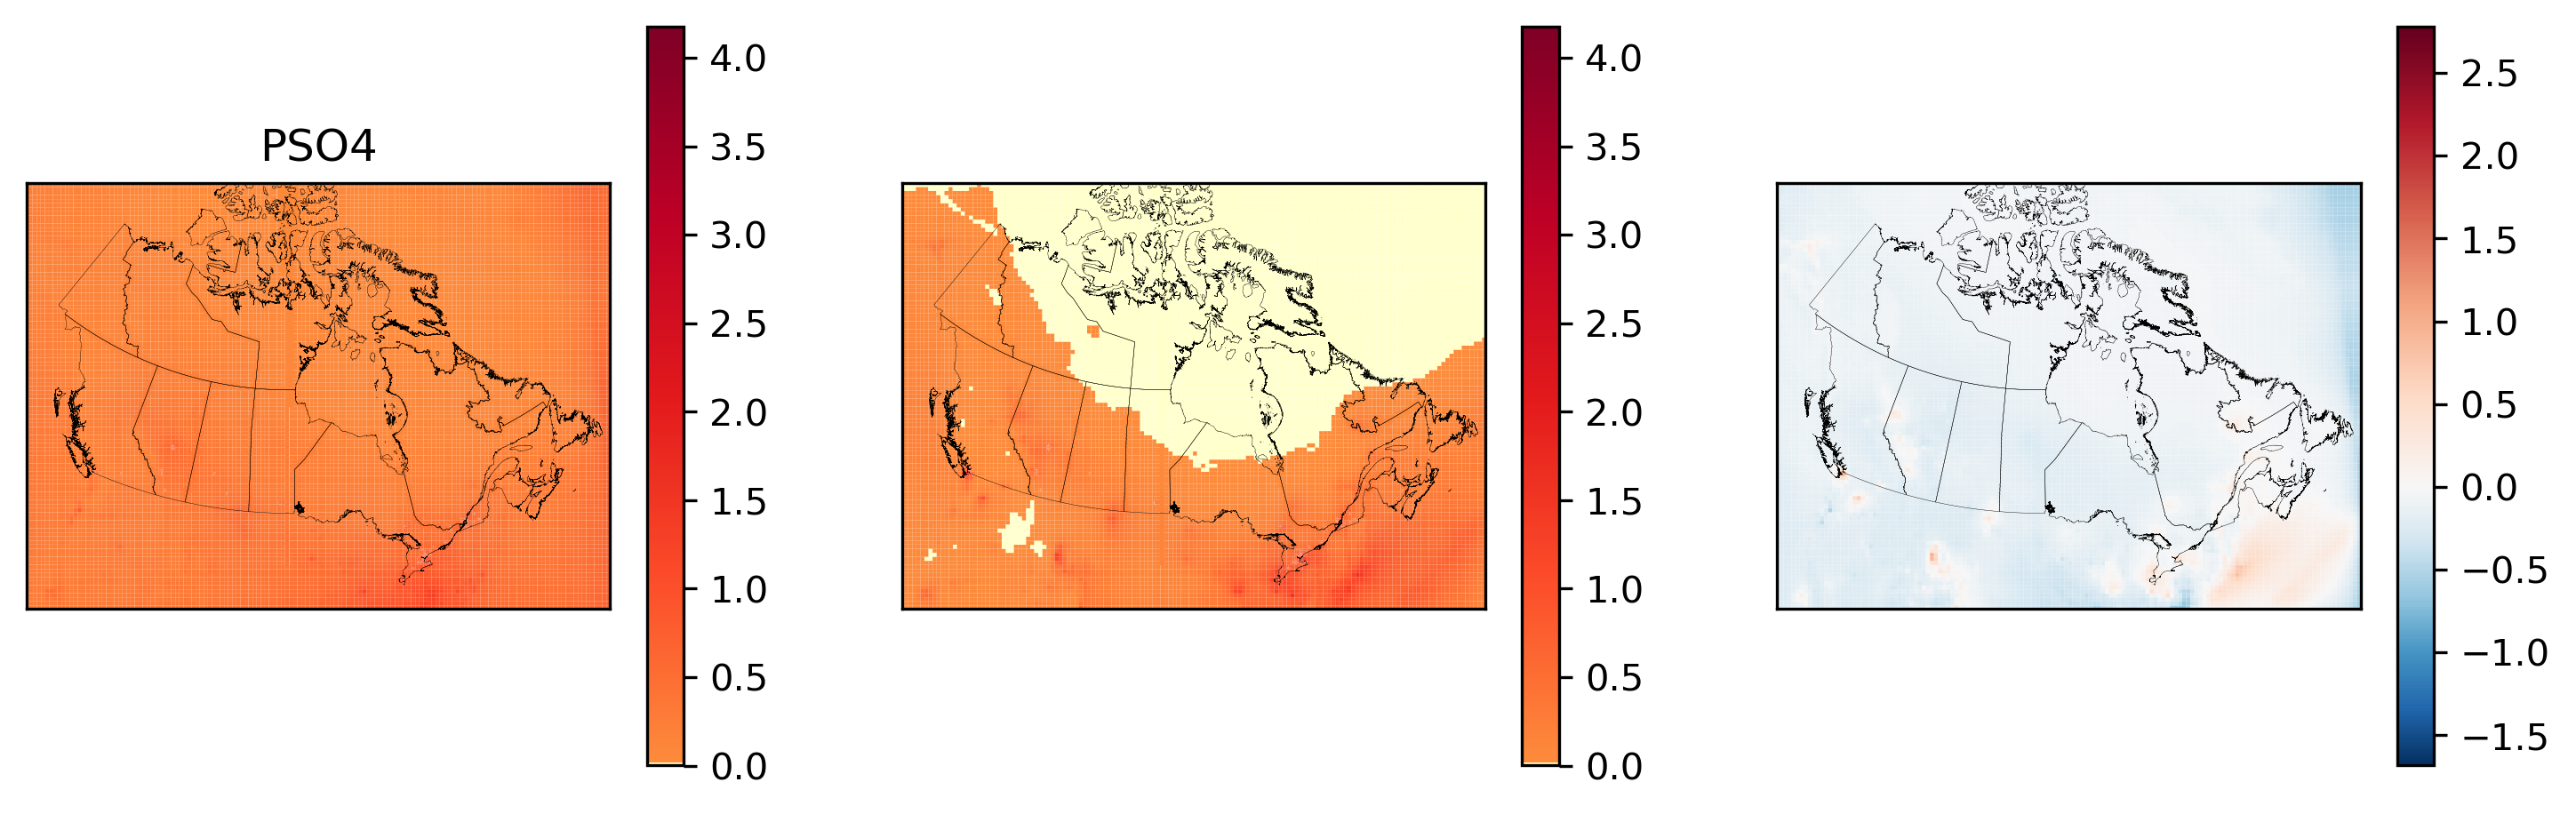

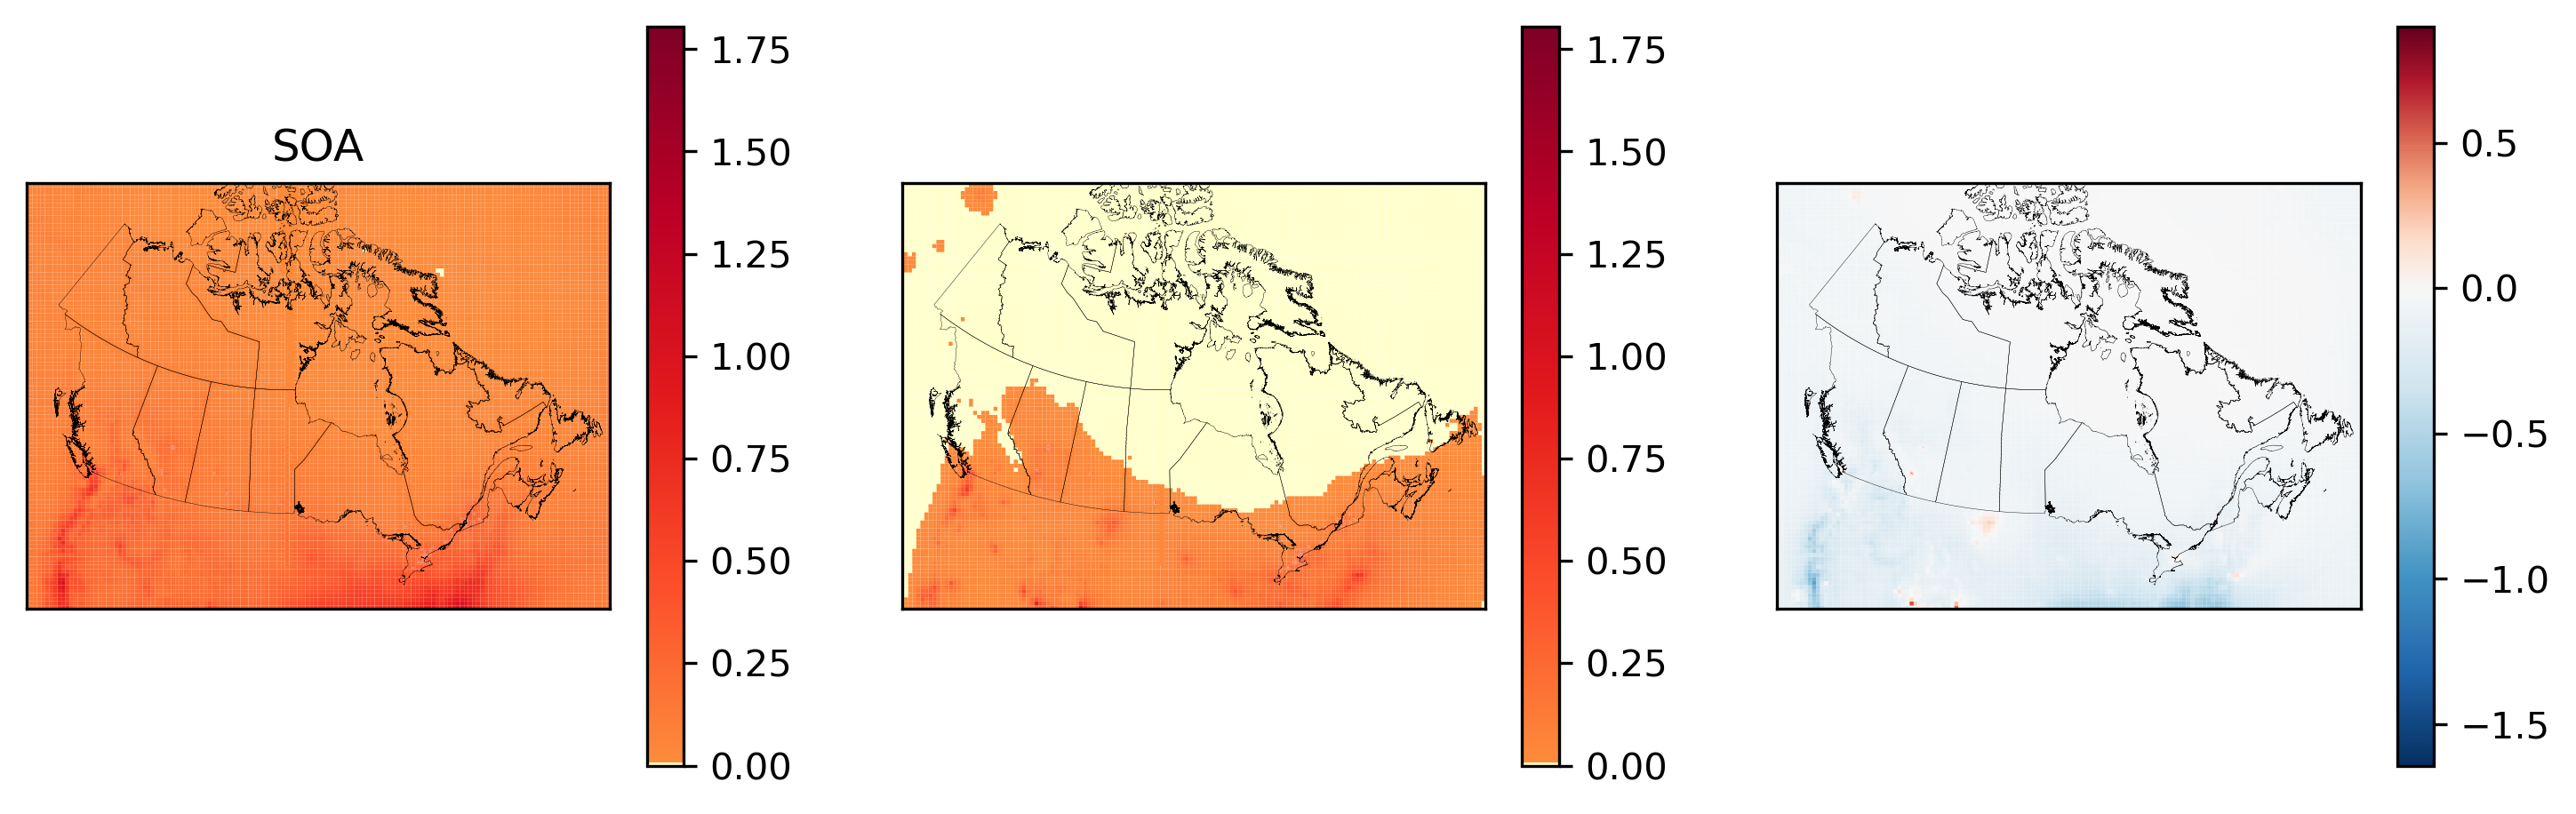

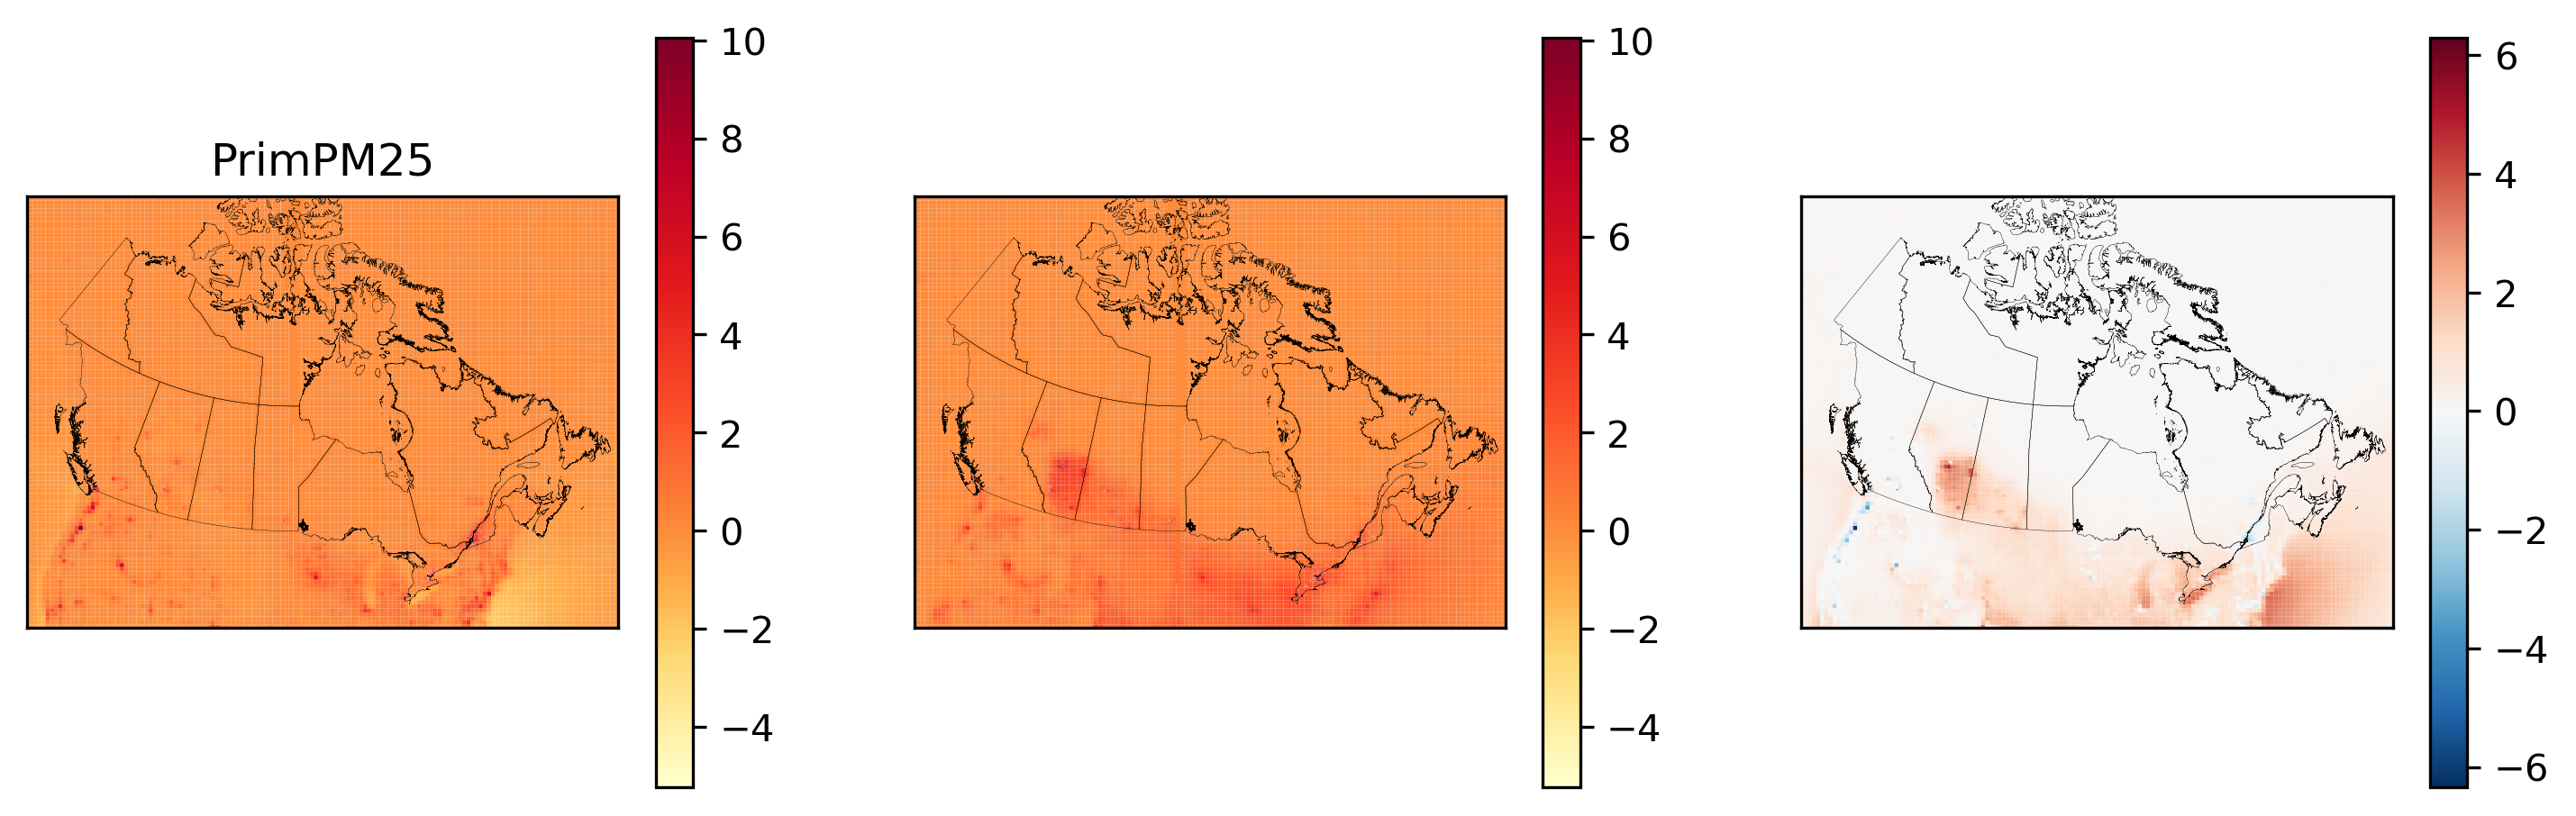

In [35]:
cmap=matplotlib.cm.YlOrRd
fig = ihf.plot_pollutants(inmap_outs,provinces,legend=True,lgdshk = 0.3,lnwdth = 0.05,alpha = 1.0,
                              cmap=cmap,listvals=pairs,figpath=figpath,scenario=scenario+'_'+prefix[:8],diff=True,xylims=xylims)
fig.show()

In [36]:
#statdf function - calculates summary stats for different pairs of values in different regions, defined by "geoareas" (currently provinces)
areastatdf = ihf.summstats(inmap_outs,pairs,stats,geoareas,popwt=None,geoname='PRENAME',popcol='TotalPop')
#areastatdf.to_csv(figpath+scenario+'_areasummstats.csv')
popstatdf = ihf.summstats(inmap_outs,pairs,stats,geoareas,popwt=True,geoname='PRENAME',popcol='TotalPop')
#popstatdf.to_csv(figpath+scenario+'_popsummstats.csv')
areastatdf.head()

D:\Github\InMAP_Canada\data_scripts\inmap_funcs.py:256: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m,r2 = res.params[0],res.rsquared
D:\Github\InMAP_Canada\data_scripts\inmap_funcs.py:256: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m,r2 = res.params[0],res.rsquared
D:\Github\InMAP_Canada\data_scripts\inmap_funcs.py:256: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  m,r2 = res.params[0],res.rsquared
D:\Github\InMAP_Canada\data_

,index,Location,RMSE,MeanBias,MeanError,MeanFractionalBias,MeanFractionalError,ModelRatio,Slope,r²
0,PM25,Canada,1.112757,0.108687,0.702637,-0.701106,1.008001,0.764927,0.715026,0.792877
1,PNO3,Canada,0.46161,-0.089256,0.264275,-0.624425,0.87681,0.76238,0.920993,0.738474
2,PNH4,Canada,0.359636,0.124177,0.196723,-0.755115,1.373931,1.164337,0.342267,0.752971
3,PSO4,Canada,0.309965,-0.215358,0.238981,-1.207149,1.245373,0.321699,1.204262,0.510849
4,SOA,Canada,0.265376,-0.147475,0.151857,-1.645174,1.654721,0.129192,2.180287,0.506195


In [37]:
popstatdf.head()

,index,Location,RMSE,MeanBias,MeanError,MeanFractionalBias,MeanFractionalError,ModelRatio,Slope,r²
0,PM25,Canada,2.141702,0.420307,1.630041,0.10505,0.325078,1.208146,0.902268,0.902629
1,PNO3,Canada,0.476123,-0.227676,0.371287,-0.111419,0.300088,0.96002,1.177563,0.935781
2,PNH4,Canada,0.689051,0.533148,0.543551,0.645093,0.708221,2.227655,0.428548,0.921065
3,PSO4,Canada,0.245712,0.038777,0.166732,-0.0798,0.311719,1.005177,0.819111,0.899426
4,SOA,Canada,0.15274,-0.020339,0.120195,-0.373378,0.568955,0.810233,0.813212,0.827048
